In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Part 1

In [10]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")
print(df.shape)
df.head()

(50, 15)


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [11]:
# Note from Mustafa to Yusuf: I added this to Verify brand_share sums to 1 within each year
print(df.groupby('year')['brand_share'].sum())

year
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
Name: brand_share, dtype: float64


In [12]:
# Part 1 - verifying that only 10 brands exist from the years 2019-2023
print("Number of brands:", df['brand'].nunique())
print("\nYears:", sorted(df['year'].unique()))

Number of brands: 10

Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


## Part 2 - Plotting

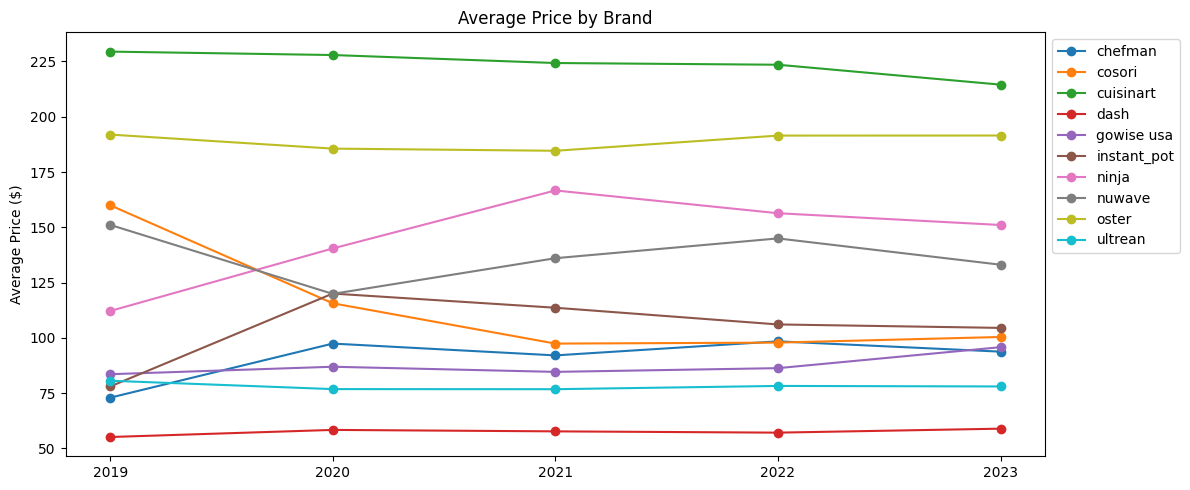

In [23]:
# Price  # Note from Mustafa to Yusuf: I split the plots into 3 cells with code and below eacg, a markdown explaining the plots.
fig, ax = plt.subplots(figsize=(12, 5))
for brand in df['brand'].unique():
    sub = df[df['brand'] == brand]
    ax.plot(sub['year'], sub['avg_price'], marker='o', label=brand)
ax.set_title('Average Price by Brand')
ax.set_ylabel('Average Price ($)')
ax.set_xticks([2019, 2020, 2021, 2022, 2023])
ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Cuisinart is by far the most expensive brand, consistently priced around 225 throughout the period. Dash sits at the opposite end, remaining the most affordable option at roughly 55. Most other brands cluster in the 80-160 range, with Ninja showing a notable price increase peaking around 2021 before declining.

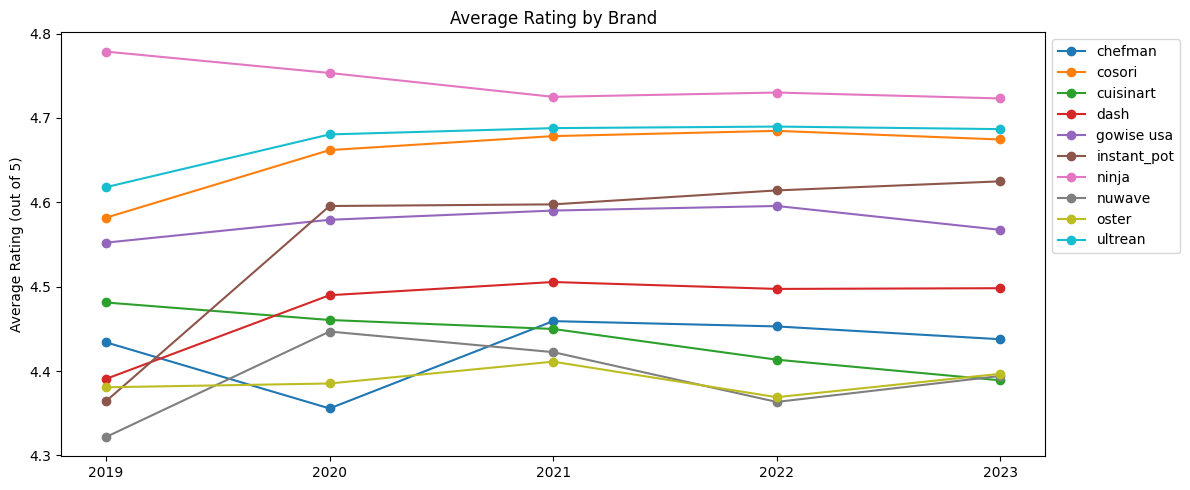

In [18]:
# Rating
fig, ax = plt.subplots(figsize=(12, 5))
for brand in df['brand'].unique():
    sub = df[df['brand'] == brand]
    ax.plot(sub['year'], sub['avg_rating'], marker='o', label=brand)
ax.set_title('Average Rating by Brand')
ax.set_ylabel('Average Rating (out of 5)')
ax.set_xticks([2019, 2020, 2021, 2022, 2023])
ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Ninja consistently leads in average ratings, hovering near 4.75 out of 5 across all years. Cuisinart and Nuwave sit at the lower end of the rating scale despite Cuisinart's premium pricing, suggesting consumers do not perceive proportionally higher quality at higher prices. Overall, ratings across all brands are relatively stable over time with little dramatic movement.

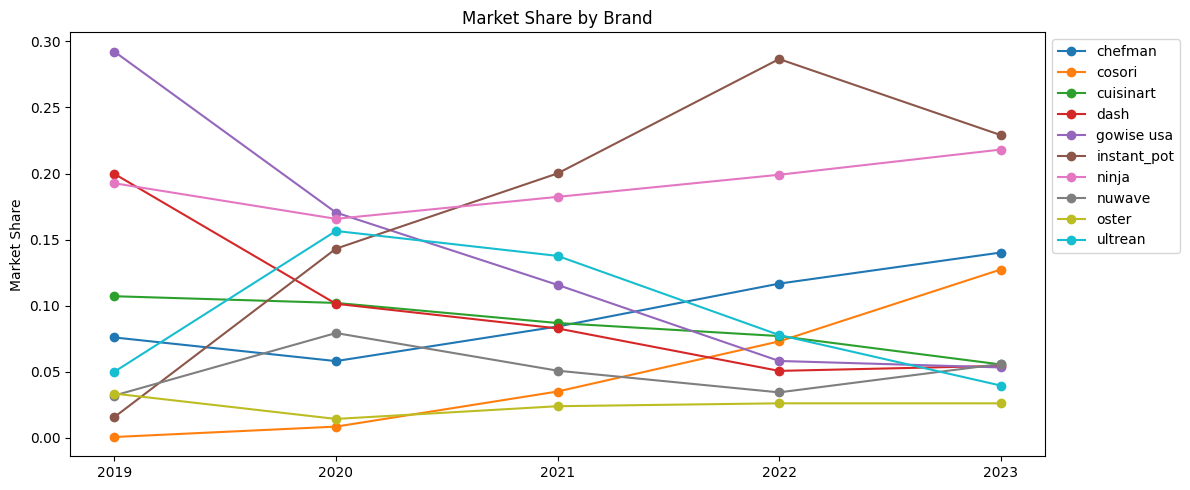

In [19]:
# Market Share
fig, ax = plt.subplots(figsize=(12, 5))
for brand in df['brand'].unique():
    sub = df[df['brand'] == brand]
    ax.plot(sub['year'], sub['brand_share'], marker='o', label=brand)
ax.set_title('Market Share by Brand')
ax.set_ylabel('Market Share')
ax.set_xticks([2019, 2020, 2021, 2022, 2023])
ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Gowise USA entered 2019 as the dominant brand but experienced a sharp and sustained decline, falling near the bottom of the market by 2023. Instant Pot moved in the opposite direction, rising steadily to become the market share leader by 2022–2023. Most other brands held relatively stable shares throughout the period, suggesting the main story of this market is the swap in dominance between these two brands.

## Part 3

In [20]:
# Part 3 - Summarizing the product characteristcs
feature_cols = ['brand', 'year', 'compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']
df_features = df[feature_cols]
df_features.head()

,brand,year,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
0,chefman,2019,1.000000,0.0,0.780977,0.243455,0.184119
1,cosori,2019,1.000000,0.0,0.090909,0.090909,0.000000
2,cuisinart,2019,0.993812,0.0,0.889851,0.000000,0.000000
3,dash,2019,1.000000,0.0,0.973431,0.000000,0.000000
4,gowise usa,2019,0.999773,0.0,0.129398,0.128490,0.000000


In [21]:
# Common features
print(df_features[feature_cols[2:]].mean().sort_values(ascending=False).to_string())

compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260


The most common features are compact and oven style. The other features do have some market share, but not as high compared to compact and oven style. The most common feature is compact. On the complete other end, the most rare featuresare dual basket and window, both of which have a very small market share for only a select few comapnies. However, as noted below, there is a significant outlier in the window share market

In [22]:
# What brands specialize in what
df_features.groupby('brand')[feature_cols[2:]].mean().round(3)

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.962,0.013,0.597,0.370,0.363
cosori,0.997,0.000,0.030,0.024,0.000
cuisinart,0.996,0.000,0.913,0.000,0.000
dash,0.999,0.000,0.890,0.000,0.000
gowise usa,1.000,0.000,0.184,0.184,0.001
instant_pot,0.860,0.000,0.675,0.102,0.003
ninja,0.992,0.002,0.100,0.000,0.000
nuwave,0.995,0.007,0.543,0.027,0.000
oster,1.000,0.000,0.865,0.000,0.000


Chefman is the most unique brand out of them all. They are the only brand with a meaningful rotisserie share (37%), and also the only brand with a meaningful window share (36.3%). Cuisinart, Dash, Oster, and Ultrean all specialize heavily in oven style air fryers with Instant Pot following a little behind. Almost every air fryerbrand specializes in compact air fryers. Only Instant Pot trails behind by speicalizing in only 86% of their shares being compact. Lastly, no company really specializes in dual basket air fryers, all market shares are roughly ≤ 1%

## Part 4


Referring back to the plots, Cuisinart is consistently at the top of the graph for average price(~$225), however, they are not rated as high as others, in fact, they are on the lower end of the rating scale (less than 4.5/5). There are some interesting trends in market share, Gowise USA begins 2019 as the largest company in the market share, but tanks significantly immediately and becomes almost the lowest market share in 2023. On the flipside, Instant Pot did the complete opposite and was leading the market share in 2022 and 2023. While individual brands shifted, the overall market structure remained relatively stable (other than these brands). The other brands within the dataset remained relatively stable over the years with no dramatic shifts.